In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
df = pd.read_csv(r"D:\DEPI R4 ML\Data Sets\adult.csv")

In [20]:
df.head()    
 


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [22]:
df.dtypes


age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

In [23]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [24]:
df.replace("?", np.nan, inplace=True)

df.isnull().sum()


age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      856
income                0
dtype: int64

In [25]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())


age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


C:\Users\omare\AppData\Local\Temp\ipykernel_10500\438386580.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\omare\AppData\Local\Temp\ipykernel_10500\438386580.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

<Axes: >

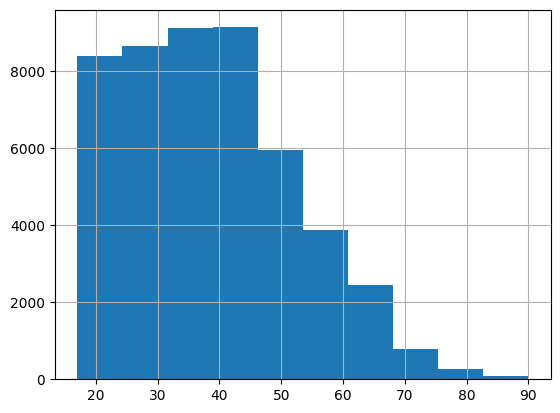

In [26]:
df["age"].hist()


<Axes: xlabel='education'>

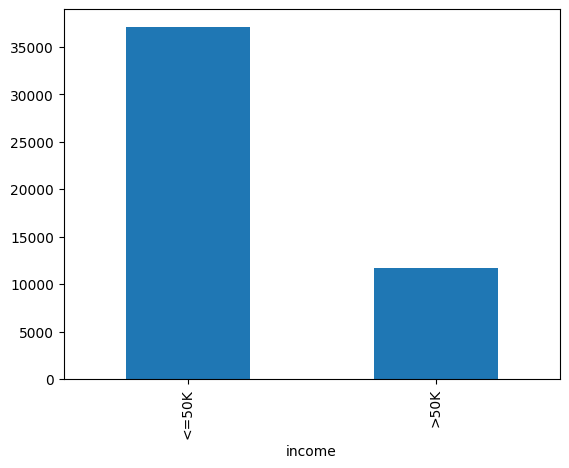

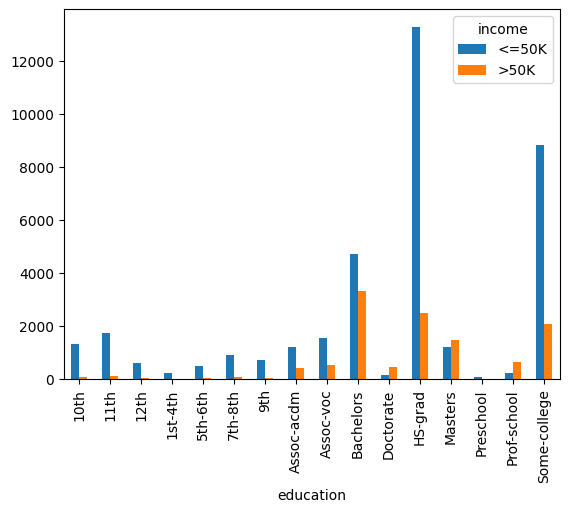

In [27]:
df["income"].value_counts().plot(kind="bar")
pd.crosstab(df["education"], df["income"]).plot(kind="bar")


<Axes: xlabel='income', ylabel='hours-per-week'>

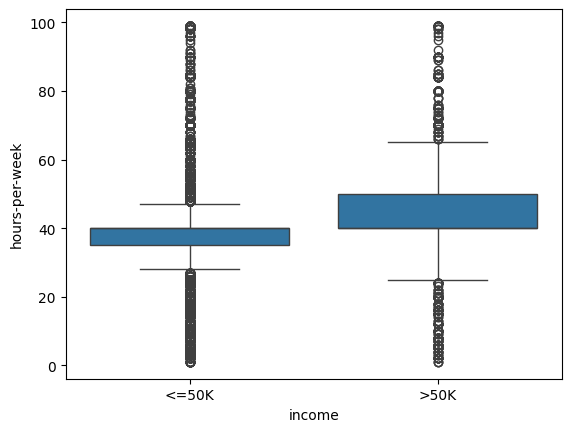

In [28]:
sns.boxplot(x="income", y="hours-per-week", data=df)


<Axes: xlabel='marital-status'>

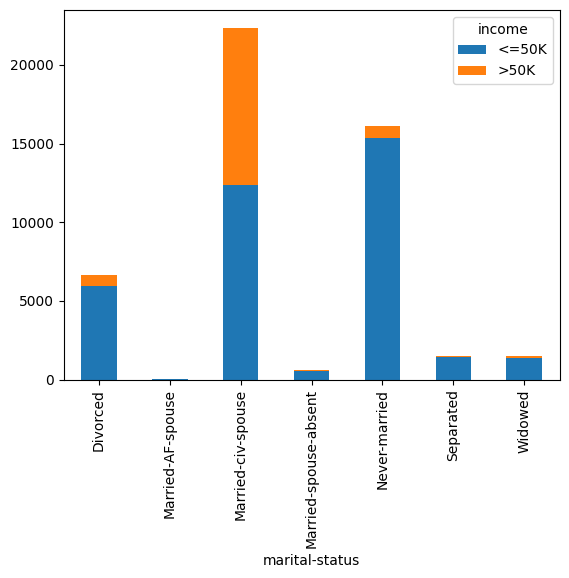

In [29]:
pd.crosstab(df["marital-status"], df["income"]).plot(kind="bar", stacked=True)


<Axes: >

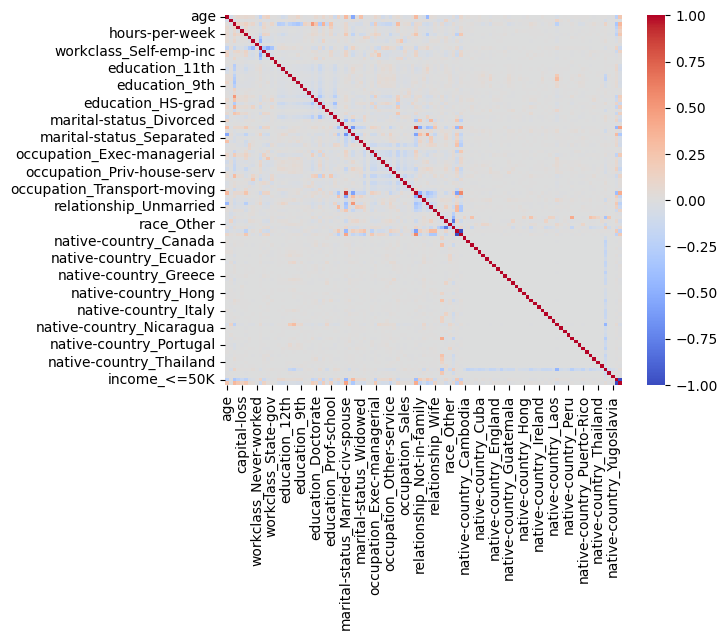

In [31]:
df_encoded = pd.get_dummies(df)
sns.heatmap(df_encoded.corr(), cmap="coolwarm")


<Axes: xlabel='capital-gain', ylabel='capital-loss'>

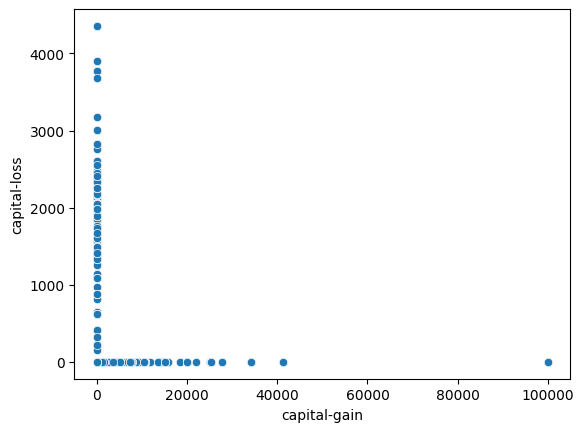

In [33]:
sns.scatterplot(x="capital-gain", y="capital-loss", data=df)


<Axes: xlabel='education', ylabel='age'>

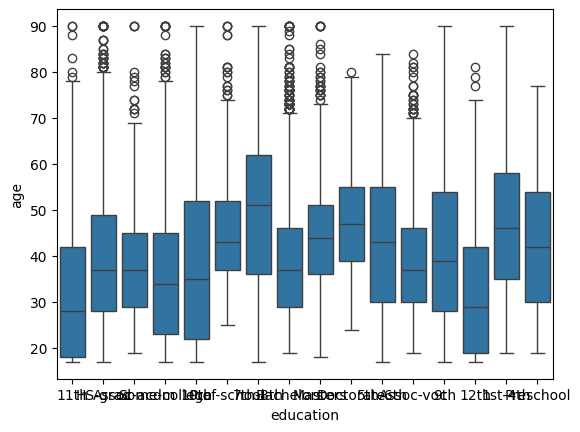

In [ ]:
sns.boxplot(x="education", y="age", data=df)
rotate_labels = plt.xticks(rotation=45)

<Axes: xlabel='education', ylabel='hours-per-week'>

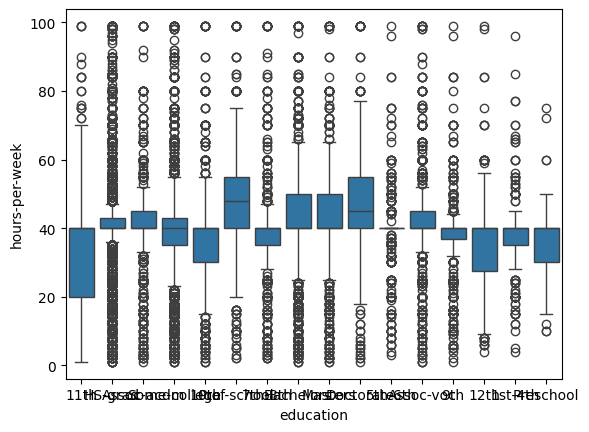

In [35]:
sns.boxplot(x="education", y="hours-per-week", data=df)


<Axes: xlabel='marital-status'>

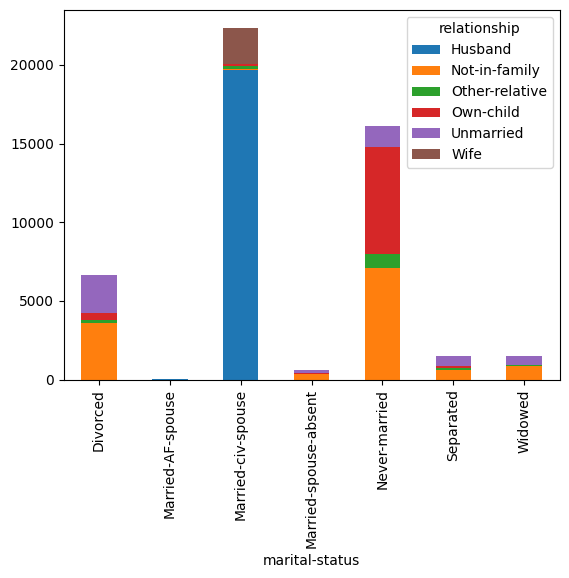

In [36]:
pd.crosstab(df["marital-status"], df["relationship"]).plot(kind="bar", stacked=True)


<Axes: xlabel='workclass'>

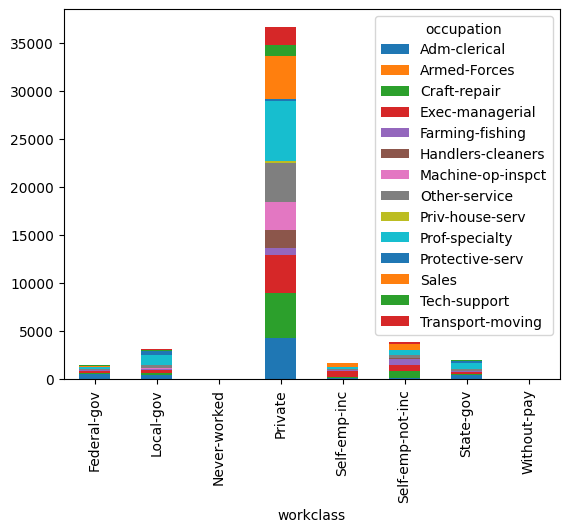

In [37]:
pd.crosstab(df["workclass"], df["occupation"]).plot(kind="bar", stacked=True)


# #feature engineering


<Axes: >

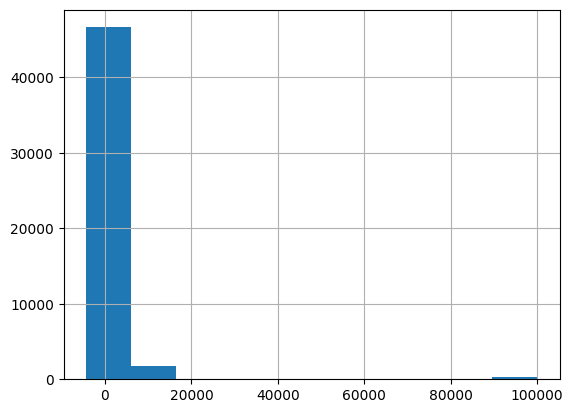

In [39]:
df["net_capital"] = df["capital-gain"] - df["capital-loss"]
df["net_capital"].hist()

<Axes: xlabel='has_capital', ylabel='income'>

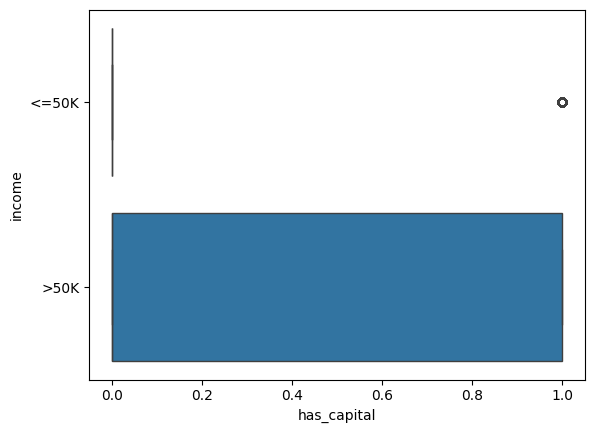

In [40]:
df["has_capital"] = ((df["capital-gain"] > 0) | (df["capital-loss"] > 0)).astype(int)
sns.boxplot(x="has_capital", y="income", data=df)

In [41]:
df.drop("education", axis=1, inplace=True)


In [42]:
df["marital-status"] = df["marital-status"].apply(
    lambda x: "Married" if "Married" in x else "Single"
)


In [43]:
df["age_group"] = pd.cut(df["age"], bins=[0,25,40,60,100], labels=["Young","Adult","Mid","Senior"])


In [44]:
df["work_intensity"] = pd.cut(
    df["hours-per-week"],
    bins=[0,25,40,60,100],
    labels=["Low","Normal","High","Extreme"]
)


In [45]:
df["capital-gain"] = np.log1p(df["capital-gain"])
df["capital-loss"] = np.log1p(df["capital-loss"])
